<a href="https://colab.research.google.com/github/sivandhana/DBA-Assignment--northstar-DB-analytics/blob/main/NorthStar_R_SQL_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 8 — SQL Integration and Statistical Analytics in R

### Objective

This section applies SQL operations within the R environment to explore structured operational records and generate statistical insights across NorthStar’s logistics system.

The aim is to combine relational querying and statistical analytics to identify operational patterns associated with service instability, customer dissatisfaction, and delivery failure behaviour.

In [2]:
# INSTALL REQUIRED PACKAGES

install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
# LOAD LIBRARIES

library(sqldf)
library(ggplot2)
library(dplyr)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
base_url <- "https://raw.githubusercontent.com/sivandhana/DBA-Assignment--northstar-DB-analytics/main/"

deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
orders <- read.csv(paste0(base_url, "orders.csv"))
customers <- read.csv(paste0(base_url, "customers.csv"))
complaints <- read.csv(paste0(base_url, "complaints.csv"))

head(deliveries)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


## SQL-Based Customer Complaint Analysis

### Objective

This query investigates whether certain customer categories experience higher complaint severity and compensation exposure.

The analysis combines customer segmentation and complaint records using SQL joins and aggregation functions.

In [5]:
str(complaints)

'data.frame':	320 obs. of  10 variables:
 $ complaint_id       : chr  "CP0001" "CP0002" "CP0003" "CP0004" ...
 $ customer_id        : chr  "C0464" "C0056" "C0469" "C0631" ...
 $ order_id           : chr  "O00814" "O00628" "O00384" "O00406" ...
 $ complaint_type     : chr  "AppIssue" "MissedPickup" "Delay" "Delay" ...
 $ channel            : chr  "App" "Phone" "Chatbot" "App" ...
 $ severity           : chr  "High" "Medium" "High" "Medium" ...
 $ created_at         : chr  "2025-03-30 02:36:00" "2024-11-07 10:05:00" "2024-01-02 15:47:00" "2025-01-14 13:07:00" ...
 $ status             : chr  "Open" "Open" "Open" "AwaitingCustomer" ...
 $ resolution_days    : int  11 4 16 7 1 9 4 18 4 1 ...
 $ compensation_amount: num  24 21.6 26.4 23.4 16.2 ...


In [6]:
# CREATE NUMERIC SEVERITY SCORE

complaints$severity_score <- ifelse(
  complaints$severity == "Low", 1,
  ifelse(
    complaints$severity == "Medium", 2,
    ifelse(complaints$severity == "High", 3, NA)
  )
)

In [7]:
# CREATE CLEAN COMPLAINTS TABLE WITH NUMERIC SEVERITY

complaints_sql <- complaints

complaints_sql$severity_score <- ifelse(
  complaints_sql$severity == "Low", 1,
  ifelse(
    complaints_sql$severity == "Medium", 2,
    ifelse(complaints_sql$severity == "High", 3, NA)
  )
)

names(complaints_sql)

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount" "severity_score"

In [8]:
# SQL QUERY — CUSTOMER COMPLAINT ANALYSIS

customer_complaint_analysis <- sqldf("

SELECT
    c.customer_type,
    COUNT(cp.complaint_id) AS total_complaints,
    ROUND(AVG(cp.severity_score), 2) AS avg_severity_score,
    ROUND(AVG(cp.compensation_amount), 2) AS avg_compensation,
    ROUND(AVG(c.loyalty_score), 2) AS avg_loyalty_score

FROM customers c

JOIN complaints_sql cp
ON c.customer_id = cp.customer_id

GROUP BY c.customer_type

ORDER BY avg_severity_score DESC

")

customer_complaint_analysis

customer_type,total_complaints,avg_severity_score,avg_compensation,avg_loyalty_score
<chr>,<int>,<dbl>,<dbl>,<dbl>
Enterprise,28,2.07,20.23,60.89
Consumer,242,2.02,20.62,61.19
SME,50,2.00,18.47,55.92


### Interpretation

The SQL join shows that Consumer customers generate the highest number of complaints, while Enterprise customers have the highest average severity score. Although severity differences are small, Enterprise complaints may require closer attention because fewer complaints still produce slightly higher severity and compensation exposure.

## Complaint Severity and Compensation Exposure by Customer Type

## Customer Complaint Exposure by Customer Type

This visualization compares complaint volume across customer groups while preserving the statistical results produced through SQL in R.

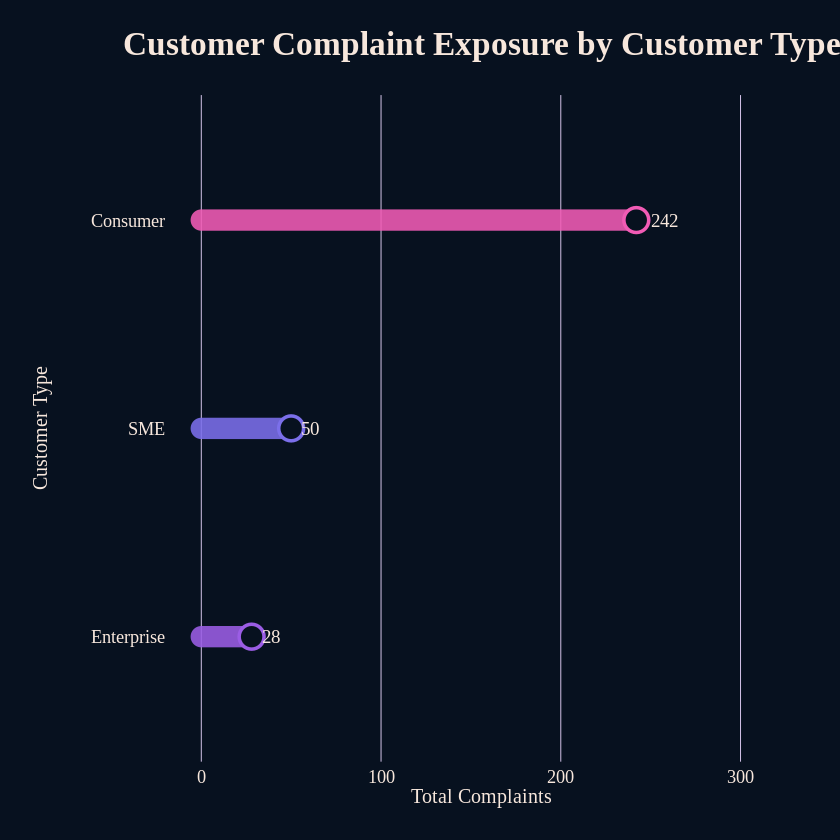

In [9]:
# CUSTOMER COMPLAINT EXPOSURE VISUALISATION

library(ggplot2)

plot_data <- customer_complaint_analysis

plot_data$customer_type <- factor(
  plot_data$customer_type,
  levels = plot_data$customer_type[order(plot_data$total_complaints)]
)

ggplot(
  plot_data,
  aes(
    x = total_complaints,
    y = customer_type,
    colour = customer_type
  )
) +

  # THIN ROUNDED BARS
  geom_segment(
    aes(
      x = 0,
      xend = total_complaints,
      y = customer_type,
      yend = customer_type
    ),
    linewidth = 6,
    lineend = "round",
    alpha = 0.88
  ) +

  # END POINTS
  geom_point(
    size = 6,
    shape = 21,
    fill = "#07111F",
    stroke = 1.5
  ) +

  # VALUE LABELS
  geom_text(
    aes(label = total_complaints),
    hjust = -0.55,
    colour = "#F7E7DC",
    size = 4
  ) +

  # CUSTOM COLOURS
  scale_colour_manual(
    values = c(
      "SME" = "#7B6FEA",
      "Enterprise" = "#9B5DE5",
      "Consumer" = "#F15BB5"
    )
  ) +

  # AXIS LIMITS
  scale_x_continuous(
    limits = c(0, max(plot_data$total_complaints) + 70)
  ) +

  # LABELS
  labs(
    title = "Customer Complaint Exposure by Customer Type",
    x = "Total Complaints",
    y = "Customer Type"
  ) +

  # THEME
  theme_minimal(base_family = "serif") +

  theme(

    plot.background = element_rect(
      fill = "#07111F",
      colour = NA
    ),

    panel.background = element_rect(
      fill = "#07111F",
      colour = NA
    ),

    panel.grid.major.x = element_line(
      colour = "#EAD7FF",
      linewidth = 0.25
    ),

    panel.grid.major.y = element_blank(),

    panel.grid.minor = element_blank(),

    plot.title = element_text(
      colour = "#F7E7DC",
      size = 20,
      face = "bold",
      hjust = 0.5,
      margin = margin(b = 20)
    ),

    axis.title = element_text(
      colour = "#F7E7DC",
      size = 12
    ),

    axis.text = element_text(
      colour = "#F7E7DC",
      size = 11
    ),

    legend.position = "none",

    plot.margin = margin(20, 30, 20, 20)

  )

## SQL-Based Delivery Performance by Service Type

This section uses SQL in R to compare delivery performance across different service types. The aim is to identify whether certain service categories experience higher delay/failure exposure and weaker customer ratings.

In [10]:
# SQL QUERY — DELIVERY PERFORMANCE BY SERVICE TYPE

delivery_service_analysis <- sqldf("

SELECT
    o.service_type,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
        100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(d.delivery_id),
        2
    ) AS failure_rate,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_fuel_or_charge_cost

FROM orders o

JOIN deliveries d
ON o.order_id = d.order_id

GROUP BY o.service_type

ORDER BY failure_rate DESC

")

delivery_service_analysis

service_type,total_deliveries,failed_deliveries,failure_rate,avg_customer_rating,avg_fuel_or_charge_cost
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
Business,126,25,19.84,3.85,13.14
Medical,108,16,14.81,3.84,12.77
Passenger,262,38,14.50,3.85,12.40
Retail,224,28,12.50,3.87,12.97
Parcel,230,25,10.87,3.90,13.08


## Service-Type Failure Pressure and Customer Satisfaction

This visualization compares operational failure exposure against customer satisfaction across major service categories.

The aim is to identify whether higher operational instability is consistently associated with weaker customer experience outcomes.

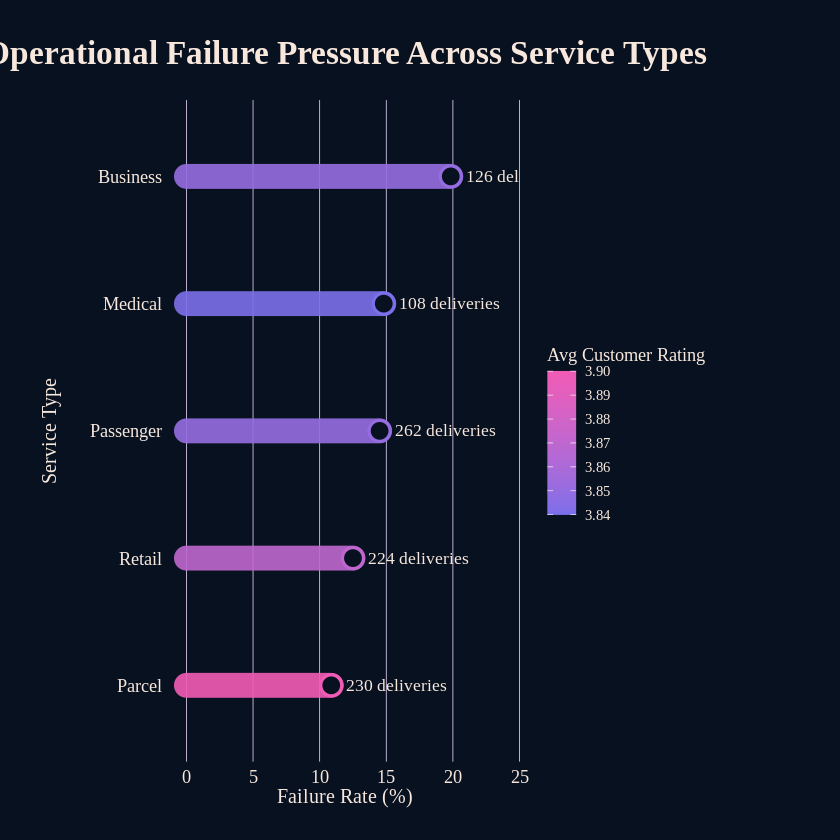

In [11]:
# SERVICE FAILURE PRESSURE VISUALISATION

library(ggplot2)

plot_data <- delivery_service_analysis

plot_data$service_type <- factor(
  plot_data$service_type,
  levels = plot_data$service_type[order(plot_data$failure_rate)]
)

ggplot(
  plot_data,
  aes(
    x = failure_rate,
    y = service_type,
    colour = avg_customer_rating
  )
) +

  # ROUNDED THIN BARS
  geom_segment(
    aes(
      x = 0,
      xend = failure_rate,
      y = service_type,
      yend = service_type
    ),
    linewidth = 7,
    lineend = "round",
    alpha = 0.9
  ) +

  # ENDPOINTS
  geom_point(
    aes(x = failure_rate),
    size = 5,
    shape = 21,
    fill = "#07111F",
    stroke = 1.4
  ) +

  # DELIVERY COUNT LABELS
  geom_text(
    aes(
      label = paste0(total_deliveries, " deliveries")
    ),
    hjust = -0.15,
    colour = "#F7E7DC",
    size = 3.7,
    family = "serif"
  ) +

  # COLOUR SCALE
  scale_colour_gradient(
    low = "#7B6FEA",
    high = "#F15BB5"
  ) +

  # AXIS LIMITS
  scale_x_continuous(
    limits = c(0, max(plot_data$failure_rate) + 4)
  ) +

  # LABELS
  labs(
    title = "Operational Failure Pressure Across Service Types",
    x = "Failure Rate (%)",
    y = "Service Type",
    colour = "Avg Customer Rating"
  ) +

  # THEME
  theme_minimal(base_family = "serif") +

  theme(

    plot.background = element_rect(
      fill = "#07111F",
      colour = NA
    ),

    panel.background = element_rect(
      fill = "#07111F",
      colour = NA
    ),

    panel.grid.major.x = element_line(
      colour = "#EAD7FF",
      linewidth = 0.22
    ),

    panel.grid.major.y = element_blank(),

    panel.grid.minor = element_blank(),

    plot.title = element_text(
      colour = "#F7E7DC",
      size = 20,
      face = "bold",
      hjust = 0.5,
      margin = margin(b = 18)
    ),

    axis.title = element_text(
      colour = "#F7E7DC",
      size = 12
    ),

    axis.text = element_text(
      colour = "#F7E7DC",
      size = 11
    ),

    legend.text = element_text(
      colour = "#F7E7DC"
    ),

    legend.title = element_text(
      colour = "#F7E7DC"
    ),

    plot.margin = margin(25, 45, 20, 25)

  )

## Service-Type Failure Pressure Analysis

This visualization compares operational failure exposure across NorthStar’s major service categories using SQL-derived aggregates generated in R.

The analysis focuses on identifying whether certain service types experience consistently higher operational instability and weaker customer satisfaction outcomes.

Warning message:
“Use of `plot_data$failure_rate` is discouraged.
ℹ Use `failure_rate` instead.”


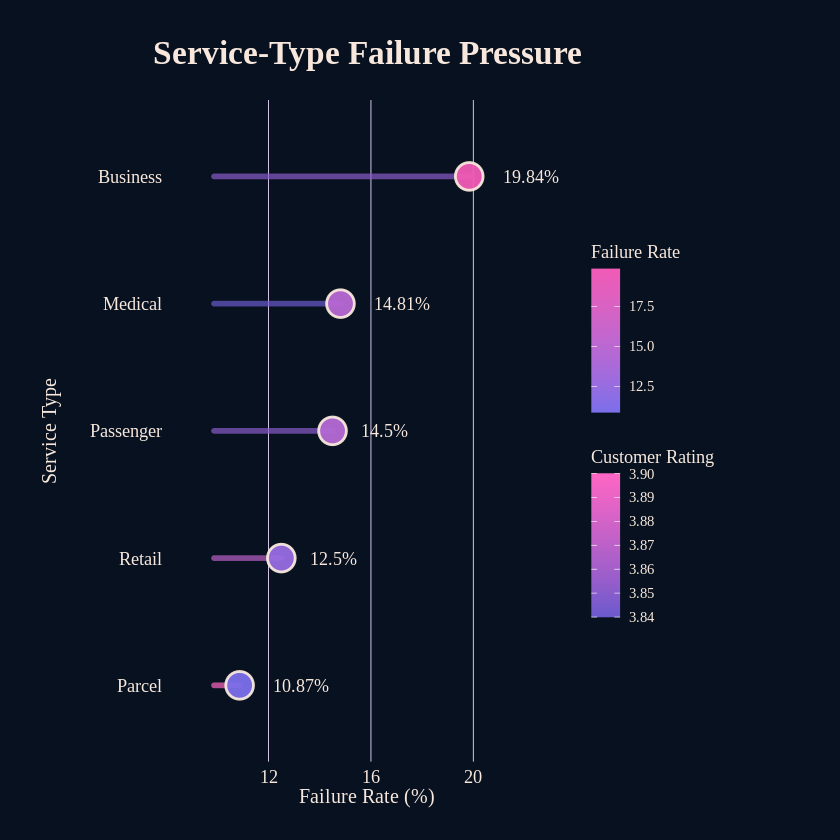

In [12]:
# SERVICE-TYPE FAILURE PRESSURE

library(ggplot2)

plot_data <- delivery_service_analysis

plot_data$service_type <- factor(
  plot_data$service_type,
  levels = plot_data$service_type[order(plot_data$failure_rate)]
)

ggplot(
  plot_data,
  aes(
    x = failure_rate,
    y = service_type
  )
) +

  # THIN LINES
  geom_segment(
    aes(
      x = min(plot_data$failure_rate) - 1,
      xend = failure_rate,
      y = service_type,
      yend = service_type,
      colour = avg_customer_rating
    ),
    linewidth = 1.6,
    alpha = 0.7,
    lineend = "round"
  ) +

  # UNIFORM DOTS
  geom_point(
    aes(
      fill = failure_rate
    ),
    size = 7,
    shape = 21,
    colour = "#F7E7DC",
    stroke = 1.2,
    alpha = 0.95
  ) +

  # FAILURE RATE LABELS
  geom_text(
    aes(label = paste0(failure_rate, "%")),
    hjust = -0.6,
    colour = "#F7E7DC",
    size = 3.8,
    family = "serif"
  ) +

  # FILL GRADIENT
  scale_fill_gradient(
    low = "#7B6FEA",
    high = "#F15BB5"
  ) +

  # LINE COLOUR GRADIENT
  scale_colour_gradient(
    low = "#6A5ACD",
    high = "#FF66C4"
  ) +

  # AXIS RANGE
  scale_x_continuous(
    limits = c(
      min(plot_data$failure_rate) - 2,
      max(plot_data$failure_rate) + 3
    )
  ) +

  # LABELS
  labs(
    title = "Service-Type Failure Pressure",
    x = "Failure Rate (%)",
    y = "Service Type",
    fill = "Failure Rate",
    colour = "Customer Rating"
  ) +

  # THEME
  theme_minimal(base_family = "serif") +

  theme(

    plot.background = element_rect(
      fill = "#07111F",
      colour = NA
    ),

    panel.background = element_rect(
      fill = "#07111F",
      colour = NA
    ),

    panel.grid.major.x = element_line(
      colour = "#EAD7FF",
      linewidth = 0.25
    ),

    panel.grid.major.y = element_blank(),

    panel.grid.minor = element_blank(),

    plot.title = element_text(
      colour = "#F7E7DC",
      size = 20,
      face = "bold",
      hjust = 0.5,
      margin = margin(b = 18)
    ),

    axis.title = element_text(
      colour = "#F7E7DC",
      size = 12
    ),

    axis.text = element_text(
      colour = "#F7E7DC",
      size = 11
    ),

    legend.text = element_text(
      colour = "#F7E7DC"
    ),

    legend.title = element_text(
      colour = "#F7E7DC"
    ),

    plot.margin = margin(25, 45, 20, 25)

  )

### Interpretation

The visualization shows that Business services experience the highest delivery failure pressure among all service categories. Parcel services maintain the lowest failure exposure, while Medical and Passenger services occupy intermediate operational risk regions.

The colour gradient further suggests that customer ratings remain relatively stable despite noticeable differences in operational failure rates, indicating that customer satisfaction may not always decline proportionally with delivery instability.

## Complaint Severity and Compensation Relationship

This section investigates whether higher complaint severity levels are associated with greater compensation exposure across NorthStar’s customer support operations.

The analysis focuses on identifying whether operational dissatisfaction translates into measurable financial remediation pressure.

In [13]:
# COMPLAINT SEVERITY VS COMPENSATION

severity_compensation <- sqldf("

SELECT
    severity,
    ROUND(AVG(compensation_amount), 2) AS avg_compensation,
    COUNT(*) AS complaint_volume

FROM complaints_sql

GROUP BY severity

ORDER BY avg_compensation DESC

")

severity_compensation

severity,avg_compensation,complaint_volume
<chr>,<dbl>,<int>
High,38.85,77
Medium,17.37,172
Low,9.06,71


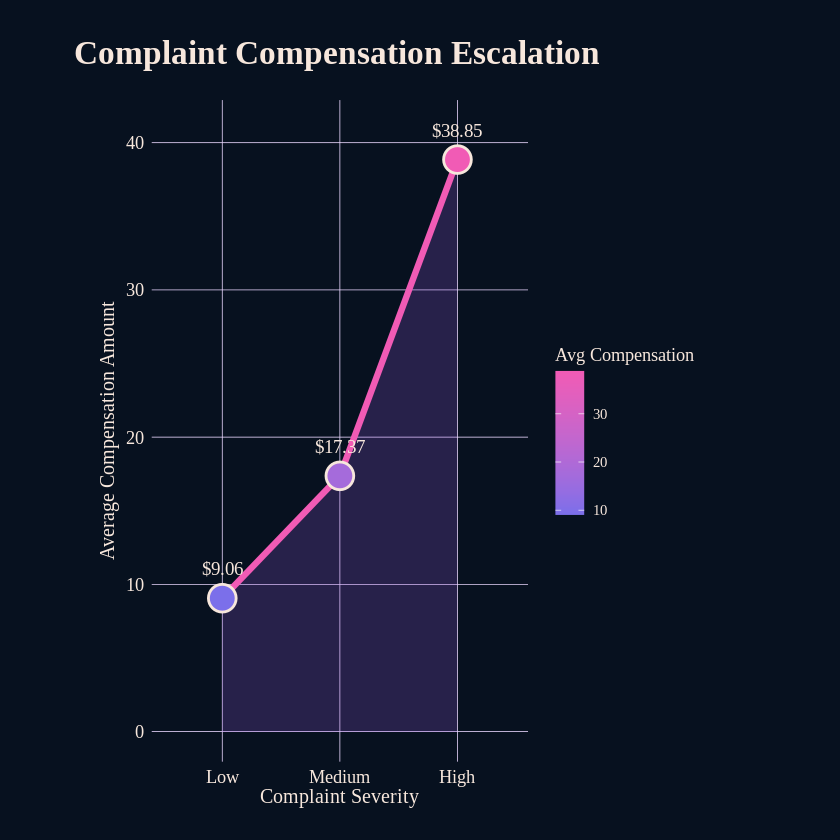

In [14]:
# SEVERITY VS COMPENSATION ESCALATION

library(ggplot2)

plot_data <- severity_compensation

plot_data$severity <- factor(
  plot_data$severity,
  levels = c("Low", "Medium", "High")
)

ggplot(
  plot_data,
  aes(
    x = severity,
    y = avg_compensation,
    group = 1
  )
) +

  # AREA GLOW
  geom_area(
    fill = "#9B5DE5",
    alpha = 0.22
  ) +

  # MAIN LINE
  geom_line(
    colour = "#F15BB5",
    linewidth = 1.8
  ) +

  # POINTS
  geom_point(
    aes(fill = avg_compensation),
    size = 7,
    shape = 21,
    colour = "#F7E7DC",
    stroke = 1.2
  ) +

  # VALUE LABELS
  geom_text(
    aes(label = paste0("$", avg_compensation)),
    colour = "#F7E7DC",
    nudge_y = 2,
    size = 4,
    family = "serif"
  ) +

  # GRADIENT
  scale_fill_gradient(
    low = "#7B6FEA",
    high = "#F15BB5"
  ) +

  # LABELS
  labs(
    title = "Complaint Compensation Escalation",
    x = "Complaint Severity",
    y = "Average Compensation Amount",
    fill = "Avg Compensation"
  ) +

  # THEME
  theme_minimal(base_family = "serif") +

  theme(

    plot.background = element_rect(
      fill = "#07111F",
      colour = NA
    ),

    panel.background = element_rect(
      fill = "#07111F",
      colour = NA
    ),

    panel.grid.major = element_line(
      colour = "#EAD7FF",
      linewidth = 0.22
    ),

    panel.grid.minor = element_blank(),

    plot.title = element_text(
      colour = "#F7E7DC",
      size = 20,
      face = "bold",
      hjust = 0.52,
      margin = margin(b = 18)
    ),

    axis.title = element_text(
      colour = "#F7E7DC",
      size = 12
    ),

    axis.text = element_text(
      colour = "#F7E7DC",
      size = 11
    ),

    legend.text = element_text(
      colour = "#F7E7DC"
    ),

    legend.title = element_text(
      colour = "#F7E7DC"
    ),

   plot.margin = margin(25, 60, 20, 60)

  )

### Interpretation

The visualization shows a strong escalation pattern between complaint severity and compensation exposure. High-severity complaints generate significantly larger compensation costs compared to Medium and Low severity cases, indicating that operational dissatisfaction can translate into measurable financial impact for NorthStar’s customer support system.

Although Medium-severity complaints occur more frequently, High-severity incidents create disproportionately higher compensation pressure, suggesting that preventing critical service failures may be financially more important than reducing minor complaints alone.

## SQL Data Manipulation Operations in R

This section demonstrates basic SQL data manipulation operations within R, including INSERT, UPDATE, and DELETE. A temporary complaints table is used so that the original dataset remains unchanged.

In [15]:
# CREATE TEMPORARY TABLE FOR SQL DATA MANIPULATION

complaints_temp <- complaints_sql

# CHECK ORIGINAL ROW COUNT
original_count <- nrow(complaints_temp)

original_count

[1] 320

In [16]:
# INSERT OPERATION

complaints_temp <- sqldf("

SELECT * FROM complaints_temp

UNION ALL

SELECT
    'CP_TEMP' AS complaint_id,
    'C_TEMP' AS customer_id,
    'O_TEMP' AS order_id,
    'Late Delivery' AS complaint_type,
    'App' AS channel,
    'High' AS severity,
    '2026-05-01' AS created_at,
    'Open' AS status,
    0 AS resolution_days,
    45.00 AS compensation_amount,
    3 AS severity_score

")

tail(complaints_temp)

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,severity_score
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
316,CP0316,C0454,O00055,MissedPickup,Phone,Medium,2025-06-05 23:44:00,Resolved,7,12.97,2
317,CP0317,C0631,O00406,DriverBehaviour,Chatbot,Medium,2025-01-17 13:07:00,Resolved,6,26.52,2
318,CP0318,C0056,O00628,Delay,App,Medium,2024-11-02 10:05:00,Open,5,20.42,2
319,CP0319,C0325,O00167,Delay,Email,Medium,2024-04-27 20:46:00,Resolved,2,11.90,2
320,CP0320,C0207,O01179,MissedPickup,Email,Medium,2025-10-16 18:48:00,Resolved,1,1.97,2
321,CP_TEMP,C_TEMP,O_TEMP,Late Delivery,App,High,2026-05-01,Open,0,45.00,3


In [17]:
# UPDATE OPERATION

complaints_temp <- sqldf("

SELECT
    complaint_id,
    customer_id,
    order_id,
    complaint_type,
    channel,
    severity,
    created_at,
    CASE
        WHEN complaint_id = 'CP_TEMP' THEN 'Resolved'
        ELSE status
    END AS status,
    CASE
        WHEN complaint_id = 'CP_TEMP' THEN 2
        ELSE resolution_days
    END AS resolution_days,
    compensation_amount,
    severity_score

FROM complaints_temp

")

complaints_temp[complaints_temp$complaint_id == "CP_TEMP", ]

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,severity_score
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
321,CP_TEMP,C_TEMP,O_TEMP,Late Delivery,App,High,2026-05-01,Resolved,2,45,3


In [19]:
# DELETE OPERATION

complaints_temp <- sqldf("

SELECT *

FROM complaints_temp

WHERE complaint_id != 'CP_TEMP'

")

final_count <- nrow(complaints_temp)

final_count

[1] 320

In [20]:
# VERIFY TEMPORARY RECORD WAS DELETED

complaints_temp[complaints_temp$complaint_id == "CP_TEMP", ]

complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,severity_score
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>


### Interpretation

The SQL manipulation workflow successfully demonstrated INSERT, UPDATE, and DELETE operations within R using a temporary complaints table. The original table contained 320 records, increased to 321 after inserting a temporary complaint, and returned to 320 after deleting it. This confirms that SQL data manipulation can be performed safely without altering the original dataset.

# R and SQL Analysis Conclusion

The R and SQL workflow provided a statistical and relational perspective on NorthStar’s operational ecosystem. SQL joins and aggregation functions were used to connect customer, complaint, order, and delivery records, while ggplot visualisations helped reveal patterns in service instability, complaint behaviour, and compensation exposure.

The analysis showed that operational pressure varies across customer groups and service categories, while higher complaint severity levels are associated with significantly greater compensation costs. Overall, the R section complemented the Python analytics workflow by providing structured statistical validation and relational data analysis capabilities.